In [6]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [7]:
device

'cuda'

In [8]:
# 데이터 로더 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [9]:
# 학습 함수
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [10]:
# 검증 함수
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [11]:
# 시각화 함수
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [108]:
# CNN 데이터 전처리
from torchvision import datasets
from torchvision.transforms import ToTensor


# 데이터 다운로드
train_set = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_set = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())


# 학습 데이터의 데이터 로더 구성
batch_size = 64
train_loader = DataLoader(train_set, batch_size = batch_size, shuffle=True)


# 검증, 테스트 데이터 준비
## 데이터 분할
x_val, x_test = test_set.data[:5000], test_set.data[5000:]
y_val, y_test = test_set.targets[:5000], test_set.targets[5000:]


## 스케일링: 0 ~ 1
x_val = x_val / 255
x_test = x_test/ 255


## 이미지 처리를 위한 차원 맞추기
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)


In [97]:
# 모델 설계
n_class = 10
model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),  
            # in_channels=1(흑백이라) (컬러면 3(RGB)이어야.)  # out_channels=32(필터 수(w개수))
            # kernel_size=3 (3X3)   # stride=1(1칸씩)   # padding=1(테두리 한 칸씩 늘린다.)
            # feature map 나옴.
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),   # 2차원이면 2d해야 함.
            # 2X2 4개의 값 중 최댓값 뽑기. stride 2면 안 겹침. 일반적으로 maxpooling은 안 겹치게 하는 게..
            # 특징 큰 영역에는 큰 값이 나오고 특징 작은 영역에는 거의 0.
            nn.Flatten(),   # 1차원으로 펼침
            nn.Linear(32*14*14, 64),    # (입력, 출력)  Flatten이후 입력 계산하는 방법이 어려움.
            nn.ReLU(),
            nn.Linear(64, n_class)  # 최종 출력층
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [14]:
# 학습
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")


# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)


# 평가
print(classification_report(y_test.numpy(), pred, digits = 4))


Epoch 1, train loss : 0.2757, val loss : 0.1756
Epoch 2, train loss : 0.0952, val loss : 0.1111
Epoch 3, train loss : 0.0652, val loss : 0.0956
Epoch 4, train loss : 0.0497, val loss : 0.0892
Epoch 5, train loss : 0.0391, val loss : 0.0819
Epoch 6, train loss : 0.0311, val loss : 0.0830
Epoch 7, train loss : 0.0237, val loss : 0.0814
Epoch 8, train loss : 0.0182, val loss : 0.0823
Epoch 9, train loss : 0.0136, val loss : 0.0877
Epoch 10, train loss : 0.0114, val loss : 0.0959
              precision    recall  f1-score   support

           0     0.9961    0.9904    0.9932       520
           1     0.9947    0.9965    0.9956       564
           2     0.9784    0.9940    0.9862       502
           3     0.9882    0.9882    0.9882       510
           4     1.0000    0.9959    0.9979       482
           5     0.9774    0.9931    0.9852       436
           6     0.9939    0.9919    0.9929       496
           7     0.9922    0.9845    0.9883       516
           8     0.9898    0.995

In [121]:
class CNN_model(nn.Module):
    def __init__(self):
        super(CNN_model, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=64,        # out_channels는
                                    kernel_size=3, stride=1, padding=1),
                                    nn.ReLU(),
                                    nn.MaxPool2d(kernel_size=2, stride=2))          # 14x14가 됨.
        self.conv2 = nn.Sequential(nn.Conv2d(in_channels=64, out_channels=128,       # in_channels와 같아야.
                                    kernel_size=3, stride=1, padding=1),
                                    nn.ReLU(),)
                                    # nn.MaxPool2d(kernel_size=2, stride=2))          # 7x7이 됨.
        self.conv3 = nn.Sequential(nn.Conv2d(in_channels=128, out_channels=256,       # in_channels와 같아야.
                                    kernel_size=3, stride=1, padding=1),
                                    nn.ReLU(),
                                    nn.MaxPool2d(kernel_size=2, stride=2))          # 7x7이 됨.
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 7 * 7, 1024)
        self.fc2 = nn.Linear(1024, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [122]:
model3 = CNN_model().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)


In [123]:
# 학습
epochs = 5
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model3, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")


# 예측
_, pred = evaluate(x_test, y_test, model3, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)


# 평가
print(classification_report(y_test.numpy(), pred, digits = 4))

# lr-0.002 : 0.4


Epoch 1, train loss : 0.1200, val loss : 0.0607
Epoch 2, train loss : 0.0385, val loss : 0.0480
Epoch 3, train loss : 0.0227, val loss : 0.0380
Epoch 4, train loss : 0.0181, val loss : 0.0415
Epoch 5, train loss : 0.0132, val loss : 0.0404
              precision    recall  f1-score   support

           0     0.9981    0.9923    0.9952       520
           1     0.9982    0.9929    0.9956       564
           2     0.9960    0.9940    0.9950       502
           3     0.9961    1.0000    0.9980       510
           4     0.9979    0.9938    0.9958       482
           5     1.0000    0.9931    0.9965       436
           6     0.9880    1.0000    0.9940       496
           7     0.9923    0.9942    0.9932       516
           8     0.9979    0.9979    0.9979       485
           9     0.9878    0.9939    0.9908       489

    accuracy                         0.9952      5000
   macro avg     0.9952    0.9952    0.9952      5000
weighted avg     0.9952    0.9952    0.9952      5000



In [ ]:
class CNN_model2(nn.Module):
    def __init__(self):
        super(CNN_model2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
    def forward(self, x):
        print(f"입력 크기: {x.shape}")
        x = self.relu(self.conv1(x))
        print(f"Conv1 출력 크기: {x.shape}")
        x = self.pool1(x)
        print(f"MaxPool1 출력 크기: {x.shape}")
        x = self.relu(self.conv2(x))
        print(f"Conv2 출력 크기: {x.shape}")
        x = self.pool2(x)
        print(f"MaxPool2 출력 크기: {x.shape}")
        return x


In [ ]:
model2 = CNN_model2()
input = x_test[0:10]
output = model2(input)

# 마지막 것만 있으면 됨. Linear 입력 계산해야 하니.

입력 크기: torch.Size([10, 1, 28, 28])
Conv1 출력 크기: torch.Size([10, 32, 28, 28])
MaxPool1 출력 크기: torch.Size([10, 32, 14, 14])
Conv2 출력 크기: torch.Size([10, 64, 14, 14])
MaxPool2 출력 크기: torch.Size([10, 64, 7, 7])


In [127]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# Colab의 파일 업로드 대신, 로컬에 있는 이미지 경로를 직접 지정합니다.
img_path = "02.png"  # 실제 이미지 파일 경로로 바꿔주세요


(28, 28)


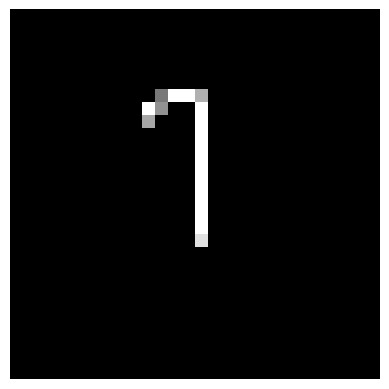

In [128]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {img_path}")


img = cv2.resize(255 - img, (28, 28))
print(img.shape)


# cv2_imshow(Colab 전용) 대신 matplotlib으로 이미지 확인
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


In [129]:
new_data = img.reshape(1, 1, 28, 28)
new_data = new_data / 255
new_data = torch.tensor(new_data, dtype=torch.float32)


In [130]:
model3.eval()  # 모델을 평가 모드로 전환
with torch.no_grad():  # 그래디언트 계산 비활성화(메모리 사용을 줄이고 속도 향상)
    new_data = new_data.to(device)  # 입력 데이터를 모델과 동일한 디바이스로 이동
    pred = model3(new_data)  # 모델에 입력 데이터를 넣어 예측 수행
    pred = nn.functional.softmax(pred, dim=1)  # 범주별 확률로 변환(소프트맥스 적용)
    pred = np.argmax(pred.cpu().numpy(), axis=1)  # 가장 확률 높은 범주의 인덱스 추출


print(pred)


[3]
